In [20]:
"""
odor_valve_generator_v3.py
=========================

Two-stage calibration for bilateral binary valve commands.

What you can specify (experiment design knobs)
----------------------------------------------
Marginals (independent per side):
  - on_rate_left, on_rate_right  : desired ON fraction (duty cycle proxy)
  - freq_left_hz, freq_right_hz  : switching speed / pulse-rate proxy

Bilateral dependence (design intent):
  - lag_s : correlation should peak near this lag (Right delayed by +lag_s)
  - tau_s : *latent* dependence envelope time constant (AR(1)/OU timescale)
  - w     : shared fraction of the latent drive (controls peak dependence)

Key point:
----------
Binary valve streams are a nonlinear transformation of latent Gaussian drivers
(CDF + state-dependent Markov switching), so the *binary* cross-correlation decay
time constant tau_eff generally differs from tau_s.

Therefore we implement:
  INNER calibration: choose w to hit target_peak_xcorr_binary
  OUTER calibration: choose tau_s so that (after re-calibrating w) the measured
                     binary tau_eff matches target_tau_eff_s.

Upgrades implemented:
---------------------
1) Stationarity-preserving lag: circular shift on a long sequence + crop center.
2) Separate correlated streams for ON and OFF transitions (avoids state-dependent
   re-use of the same noise stream).
3) Robust (non-monotonic-safe) outer search over tau using log-spaced coarse-to-fine
   grid search; no assumption that tau_eff(tau_s) is perfectly monotone.

Dependencies: numpy only.
"""

from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List
import numpy as np
from scipy.special import erf
import math
import matplotlib.pyplot as plt


# -----------------------------
# Basics: Normal CDF using erf
# -----------------------------
def norm_cdf(z: np.ndarray) -> np.ndarray:
    z = np.asarray(z, dtype=float)
    return 0.5 * (1.0 + erf(z / np.sqrt(2.0)))


# --------------------------------------
# Markov rates: on-fraction + "frequency"
# --------------------------------------
def markov_rates_from_onrate_and_freq(p_on: float, freq_hz: float) -> Tuple[float, float]:
    """
    Map (stationary ON fraction p_on, frequency-like switching scale freq_hz) to CTMC rates.

    CTMC stationary ON fraction:
        p_on = alpha / (alpha + beta)

    Choose (convenient mapping):
        alpha = freq_hz / (1 - p_on)
        beta  = freq_hz / p_on

    Discretize at timestep dt:
        p = alpha*dt  (OFF->ON per step)
        q = beta*dt   (ON->OFF per step)

    This gives intuitive control of switching speed and mean ON fraction.
    """
    p = np.clip(float(p_on), 1e-8, 1.0 - 1e-8)
    f = max(float(freq_hz), 0.0)
    alpha = f / (1.0 - p)
    beta = f / p
    return alpha, beta


# -----------------------------
# Stationary AR(1) generator
# -----------------------------
def ar1_process(n: int, a: float, rng: np.random.Generator) -> np.ndarray:
    """
    Stationary, unit-variance AR(1):
        x_t = a x_{t-1} + sqrt(1-a^2) eps_t, eps_t ~ N(0,1)
    """
    if not (-1.0 < a < 1.0):
        raise ValueError("AR coefficient a must be in (-1,1).")
    eps = rng.standard_normal(n)
    x = np.empty(n, dtype=float)
    x[0] = eps[0]  # start at stationarity (N(0,1))
    s = np.sqrt(max(1.0 - a * a, 0.0))
    for i in range(1, n):
        x[i] = a * x[i - 1] + s * eps[i]
    return x


# -----------------------------
# Correlation utilities
# -----------------------------
def pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson correlation; returns 0 for constant signals."""
    x = x.astype(float) - float(np.mean(x))
    y = y.astype(float) - float(np.mean(y))
    denom = np.sqrt(float(np.mean(x * x))) * np.sqrt(float(np.mean(y * y)))
    return 0.0 if denom == 0 else float(np.mean(x * y) / denom)


def corr_at_lag(x: np.ndarray, y: np.ndarray, lag: int) -> float:
    """Corr(x_t, y_{t+lag}). Positive lag means y is delayed vs x."""
    lag = int(lag)
    if lag == 0:
        return pearson_corr(x, y)
    if lag > 0:
        return pearson_corr(x[:-lag], y[lag:])
    lag = -lag
    return pearson_corr(x[lag:], y[:-lag])


def xcorr_curve(x: np.ndarray, y: np.ndarray, max_lag: int) -> Tuple[np.ndarray, np.ndarray]:
    """Cross-correlation for lags in [-max_lag, +max_lag]."""
    lags = np.arange(-int(max_lag), int(max_lag) + 1)
    vals = np.array([corr_at_lag(x, y, k) for k in lags], dtype=float)
    return lags, vals


def peak_near_lag(x: np.ndarray, y: np.ndarray, target_lag: int, window: int) -> Tuple[float, int]:
    """Peak correlation within [target_lag-window, target_lag+window]."""
    lo = int(target_lag - window)
    hi = int(target_lag + window)
    lags = np.arange(lo, hi + 1)
    vals = np.array([corr_at_lag(x, y, k) for k in lags], dtype=float)
    i = int(np.nanargmax(vals))
    return float(vals[i]), int(lags[i])


def fit_exp_decay_about_peak(
    lags: np.ndarray,
    xcorr: np.ndarray,
    peak_lag: int,
    fit_radius_lags: int,
    fs: float,
    min_abs_corr: float = 1e-3
) -> Dict[str, float]:
    """
    Fit |xcorr(lag)| ≈ A * exp(-|lag-peak_lag| / lambda_lags) in a window around the peak.

    Returns:
      lambda_lags, tau_eff_s=lambda_lags/fs, A, r2, n_points
    """
    lags = np.asarray(lags)
    xcorr = np.asarray(xcorr)
    d = np.abs(lags - int(peak_lag))

    mask = (d >= 1) & (d <= int(fit_radius_lags)) & (np.abs(xcorr) >= float(min_abs_corr))
    if int(mask.sum()) < 3:
        return {"lambda_lags": np.nan, "tau_eff_s": np.nan, "A": np.nan, "r2": np.nan, "n_points": float(mask.sum())}

    x = d[mask].astype(float)
    y = np.log(np.abs(xcorr[mask]).astype(float))

    X = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    logA, slope = float(beta[0]), float(beta[1])

    lam = np.inf if slope >= 0 else -1.0 / slope
    A = float(np.exp(logA))

    yhat = X @ beta
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "lambda_lags": float(lam),
        "tau_eff_s": float(lam / float(fs)),
        "A": A,
        "r2": float(r2),
        "n_points": float(mask.sum()),
    }


# -----------------------------
# Result container
# -----------------------------
@dataclass
class OdorPair:
    t: np.ndarray
    left: np.ndarray
    right: np.ndarray
    info: Dict[str, object]


# ============================================================
# Core generator (stationary crop + separate ON/OFF streams)
# ============================================================
def generate_odor_pair(
    duration_s: float,
    fs: float,

    on_rate_left: float,
    on_rate_right: float,
    freq_left_hz: float,
    freq_right_hz: float,

    lag_s: float,
    tau_s: float,

    # If w_override is provided, we use it (no calibration here).
    w_override: Optional[float] = None,

    # Calibration-only settings (ignored if w_override is not None)
    target_peak_xcorr_binary: Optional[float] = None,
    peak_search_window_s: float = 0.05,
    calibrate_w: bool = False,
    n_calib_iters: int = 14,
    n_trials_per_step: int = 2,

    # Reporting / fitting
    max_lag_report_s: float = 0.5,
    fit_radius_s: float = 0.25,

    # Stationarity padding (auto if None)
    pad_s: Optional[float] = None,

    seed: int = 0,
) -> OdorPair:
    """
    Generate binary valve commands with the updated method:
      - circularly-shifted common AR(1) + center crop (stationary)
      - separate correlated ON- and OFF-hazard streams

    This function can either:
      A) use a provided w_override, or
      B) calibrate w to match target_peak_xcorr_binary (inner loop).

    Returns OdorPair with info including measured peak corr and tau_eff fit.
    """
    rng = np.random.default_rng(seed)

    fs = float(fs)
    dt = 1.0 / fs

    lag_steps = int(np.round(float(lag_s) * fs))
    win_steps = int(np.round(float(peak_search_window_s) * fs))
    max_lag = int(np.round(float(max_lag_report_s) * fs))
    fit_radius_lags = int(np.round(float(fit_radius_s) * fs))

    tau_s = float(max(tau_s, 1e-6))
    a = float(np.exp(-dt / tau_s))

    # Choose pad large enough that roll wrap-around never contaminates the crop
    if pad_s is None:
        pad_steps = max(
            abs(lag_steps),
            int(np.round(2.0 * tau_s * fs)),
            int(np.round(1.0 * fs)),
        )
    else:
        pad_steps = max(abs(lag_steps), int(np.round(float(pad_s) * fs)))

    n_main = int(np.round(float(duration_s) * fs))
    n_total = n_main + 2 * pad_steps

    # Markov per-step transition probabilities
    alpha_L, beta_L = markov_rates_from_onrate_and_freq(on_rate_left, freq_left_hz)
    alpha_R, beta_R = markov_rates_from_onrate_and_freq(on_rate_right, freq_right_hz)
    pL = float(np.clip(alpha_L * dt, 0.0, 1.0))
    qL = float(np.clip(beta_L * dt, 0.0, 1.0))
    pR = float(np.clip(alpha_R * dt, 0.0, 1.0))
    qR = float(np.clip(beta_R * dt, 0.0, 1.0))

    crop = slice(pad_steps, pad_steps + n_main)

    def _simulate_once(w: float) -> Tuple[np.ndarray, np.ndarray]:
        """
        Simulate one trial, returning binary (L,R) cropped to length n_main.
        """
        w = float(np.clip(w, 0.0, 1.0))
        w_priv = np.sqrt(max(1.0 - w * w, 0.0))

        # Separate common processes for ON-hazard and OFF-hazard
        common_on = ar1_process(n_total, a, rng)
        common_off = ar1_process(n_total, a, rng)

        # Private processes (independent across side and hazard type)
        priv_on_L = ar1_process(n_total, a, rng)
        priv_on_R = ar1_process(n_total, a, rng)
        priv_off_L = ar1_process(n_total, a, rng)
        priv_off_R = ar1_process(n_total, a, rng)

        # Right delayed by +lag_steps => read earlier common samples:
        # achieve by np.roll(common, shift=+lag_steps), then crop center.
        common_on_R = np.roll(common_on, shift=lag_steps)
        common_off_R = np.roll(common_off, shift=lag_steps)

        Xon_L = (w * common_on + w_priv * priv_on_L)[crop]
        Xon_R = (w * common_on_R + w_priv * priv_on_R)[crop]
        Xoff_L = (w * common_off + w_priv * priv_off_L)[crop]
        Xoff_R = (w * common_off_R + w_priv * priv_off_R)[crop]

        u_on_L = norm_cdf(Xon_L)
        u_on_R = norm_cdf(Xon_R)
        u_off_L = norm_cdf(Xoff_L)
        u_off_R = norm_cdf(Xoff_R)

        L = np.zeros(n_main, dtype=np.uint8)
        R = np.zeros(n_main, dtype=np.uint8)
        L[0] = 1 if rng.random() < on_rate_left else 0
        R[0] = 1 if rng.random() < on_rate_right else 0

        for i in range(1, n_main):
            # left
            if L[i - 1] == 0:
                L[i] = 1 if u_on_L[i] < pL else 0
            else:
                L[i] = 0 if u_off_L[i] < qL else 1
            # right
            if R[i - 1] == 0:
                R[i] = 1 if u_on_R[i] < pR else 0
            else:
                R[i] = 0 if u_off_R[i] < qR else 1

        return L, R

    def _binary_peak_metric(w: float) -> float:
        vals = []
        for _ in range(int(n_trials_per_step)):
            L, R = _simulate_once(w)
            pk, _ = peak_near_lag(L, R, target_lag=lag_steps, window=win_steps)
            vals.append(pk)
        return float(np.mean(vals))

    # -------- inner calibration for w --------
    if w_override is not None:
        w_used = float(np.clip(w_override, 0.0, 1.0))
    else:
        w_used = 0.0
        if calibrate_w and (target_peak_xcorr_binary is not None):
            target = float(target_peak_xcorr_binary)
            lo, hi = 0.0, 1.0
            f_lo = _binary_peak_metric(lo) - target
            f_hi = _binary_peak_metric(hi) - target

            # If not bracketed, choose closest among {0, 0.5, 1}
            if np.isnan(f_lo) or np.isnan(f_hi) or (f_lo * f_hi > 0):
                mid = 0.5
                cands = [
                    (lo, abs(f_lo)),
                    (mid, abs(_binary_peak_metric(mid) - target)),
                    (hi, abs(f_hi)),
                ]
                w_used = min(cands, key=lambda x: x[1])[0]
            else:
                for _ in range(int(n_calib_iters)):
                    mid = 0.5 * (lo + hi)
                    f_mid = _binary_peak_metric(mid) - target
                    if f_lo * f_mid <= 0:
                        hi, f_hi = mid, f_mid
                    else:
                        lo, f_lo = mid, f_mid
                w_used = 0.5 * (lo + hi)

    # -------- final run (one trial) for output + measurement --------
    L, R = _simulate_once(w_used)

    t = np.arange(n_main) * dt

    # Measurements
    pk_bin, pk_lag_bin = peak_near_lag(L, R, target_lag=lag_steps, window=win_steps)
    lags_bin, xcorr_bin = xcorr_curve(L, R, max_lag=max_lag)
    tau_fit = fit_exp_decay_about_peak(
        lags=lags_bin,
        xcorr=xcorr_bin,
        peak_lag=pk_lag_bin,
        fit_radius_lags=max(5, fit_radius_lags),
        fs=fs,
        min_abs_corr=1e-3,
    )

    info: Dict[str, object] = {
        "fs": fs,
        "dt": dt,
        "duration_s": duration_s,

        "lag_s_target": float(lag_s),
        "lag_steps_target": int(lag_steps),

        "tau_s_latent": float(tau_s),
        "a": float(a),

        "w_used": float(w_used),

        "on_rate_left_req": float(on_rate_left),
        "on_rate_right_req": float(on_rate_right),
        "freq_left_hz_req": float(freq_left_hz),
        "freq_right_hz_req": float(freq_right_hz),

        "mean_on_left": float(L.mean()),
        "mean_on_right": float(R.mean()),

        "binary_peak_xcorr": float(pk_bin),
        "binary_peak_lag_s": float(pk_lag_bin / fs),

        "lags_s": (lags_bin / fs),
        "xcorr_binary": xcorr_bin,

        "binary_decay_fit": tau_fit,  # includes tau_eff_s
    }

    return OdorPair(t=t, left=L, right=R, info=info)


# ============================================================
# Two-stage calibration: outer tau + inner w
# ============================================================
def calibrate_tau_and_w(
    *,
    # Targets on the final binary valve time series
    target_peak_xcorr_binary: float,
    target_tau_eff_s: float,

    # Fixed design knobs
    lag_s: float,
    fs: float,
    on_rate_left: float,
    on_rate_right: float,
    freq_left_hz: float,
    freq_right_hz: float,

    # Search bounds for latent tau_s (seconds)
    tau_min_s: float = 0.02,
    tau_max_s: float = 2.0,

    # Search strategy
    n_grid: int = 9,
    n_refine_rounds: int = 3,

    # Calibration/eval durations
    calib_duration_s: float = 15.0,   # shorter = faster; longer = less noisy
    final_duration_s: float = 60.0,   # final output length

    # Inner calibration settings
    peak_search_window_s: float = 0.05,
    n_calib_iters: int = 12,
    n_trials_per_step: int = 2,

    # Evaluation robustness
    n_eval_reps: int = 2,            # average metrics across reps per tau candidate
    fit_radius_s: float = 0.25,
    max_lag_report_s: float = 0.5,

    # Loss weights (tau matching is primary)
    weight_peak: float = 0.25,       # peak error weight relative to tau error

    seed: int = 0,
) -> Tuple[OdorPair, Dict[str, object]]:
    """
    Outer search over latent tau_s (log-spaced, coarse-to-fine).
    For each tau_s candidate:
      - inner calibrate w to match target_peak_xcorr_binary
      - simulate and measure binary tau_eff_s
      - compute loss based on tau_eff error + peak error

    Returns:
      final_pair : OdorPair generated at the best tau_s (with w calibrated)
      report     : dict describing the search trace and chosen parameters

    Notes:
    - This search is intentionally robust to non-monotonicity/noise.
    - If you want maximum precision, increase calib_duration_s and n_eval_reps.
    """
    rng_master = np.random.default_rng(seed)
    seed_stream = rng_master.integers(0, 2**31 - 1, size=10_000, dtype=np.int64)
    seed_idx = 0

    def _next_seed() -> int:
        nonlocal seed_idx
        s = int(seed_stream[seed_idx])
        seed_idx += 1
        return s

    def _evaluate_tau_candidate(tau_s: float) -> Dict[str, float]:
        """
        For a given latent tau_s:
          - inner-calibrate w
          - average (peak_xcorr, tau_eff) over n_eval_reps
        """
        peaks: List[float] = []
        taus_eff: List[float] = []
        ws: List[float] = []

        for _ in range(int(n_eval_reps)):
            pair = generate_odor_pair(
                duration_s=calib_duration_s,
                fs=fs,
                on_rate_left=on_rate_left,
                on_rate_right=on_rate_right,
                freq_left_hz=freq_left_hz,
                freq_right_hz=freq_right_hz,
                lag_s=lag_s,
                tau_s=tau_s,
                w_override=None,
                target_peak_xcorr_binary=target_peak_xcorr_binary,
                peak_search_window_s=peak_search_window_s,
                calibrate_w=True,
                n_calib_iters=n_calib_iters,
                n_trials_per_step=n_trials_per_step,
                max_lag_report_s=max_lag_report_s,
                fit_radius_s=fit_radius_s,
                seed=_next_seed(),
            )
            peaks.append(float(pair.info["binary_peak_xcorr"]))
            ws.append(float(pair.info["w_used"]))
            taus_eff.append(float(pair.info["binary_decay_fit"]["tau_eff_s"]))

        peak_mean = float(np.mean(peaks))
        tau_eff_mean = float(np.mean(taus_eff))
        w_mean = float(np.mean(ws))

        # Loss: squared relative-ish errors (avoid scale issues)
        # tau term dominates; peak term helps keep peak accurate.
        tau_err = (tau_eff_mean - float(target_tau_eff_s))
        peak_err = (peak_mean - float(target_peak_xcorr_binary))
        loss = (tau_err * tau_err) + float(weight_peak) * (peak_err * peak_err)

        return {
            "tau_s": float(tau_s),
            "tau_eff_s": float(tau_eff_mean),
            "peak_xcorr": float(peak_mean),
            "w_used": float(w_mean),
            "loss": float(loss),
            "tau_err": float(tau_err),
            "peak_err": float(peak_err),
        }

    # Coarse-to-fine log-space grid refinement
    tau_min_s = float(max(tau_min_s, 1e-4))
    tau_max_s = float(max(tau_max_s, tau_min_s * 1.01))

    trace: List[Dict[str, float]] = []

    lo = np.log10(tau_min_s)
    hi = np.log10(tau_max_s)

    best = None

    for _round in range(int(n_refine_rounds)):
        taus = np.logspace(lo, hi, int(n_grid))
        results = []
        for tau in taus:
            r = _evaluate_tau_candidate(float(tau))
            trace.append(r)
            results.append(r)

        # pick best and refine around it using neighbors in log-space
        results_sorted = sorted(results, key=lambda d: d["loss"])
        best = results_sorted[0]

        # Find index of best in this grid and shrink bracket around it
        best_tau = best["tau_s"]
        idx = int(np.argmin([abs(np.log10(r["tau_s"]) - np.log10(best_tau)) for r in results]))

        # choose neighbor indices for new bracket (with clamps)
        i0 = max(0, idx - 1)
        i1 = min(len(taus) - 1, idx + 1)
        lo = np.log10(float(taus[i0]))
        hi = np.log10(float(taus[i1]))

        # if bracket collapses (edge), slightly expand locally
        if hi - lo < 1e-6:
            lo -= 0.3
            hi += 0.3

    assert best is not None
    best_tau_s = float(best["tau_s"])

    # Final output at best tau_s, with a more stable inner calibration
    final_pair = generate_odor_pair(
        duration_s=final_duration_s,
        fs=fs,
        on_rate_left=on_rate_left,
        on_rate_right=on_rate_right,
        freq_left_hz=freq_left_hz,
        freq_right_hz=freq_right_hz,
        lag_s=lag_s,
        tau_s=best_tau_s,
        w_override=None,
        target_peak_xcorr_binary=target_peak_xcorr_binary,
        peak_search_window_s=peak_search_window_s,
        calibrate_w=True,
        n_calib_iters=max(n_calib_iters, 14),
        n_trials_per_step=max(n_trials_per_step, 3),
        max_lag_report_s=max_lag_report_s,
        fit_radius_s=fit_radius_s,
        seed=_next_seed(),
    )

    report: Dict[str, object] = {
        "best_tau_s_latent": best_tau_s,
        "best_tau_eff_s_binary_est": float(final_pair.info["binary_decay_fit"]["tau_eff_s"]),
        "best_w_used": float(final_pair.info["w_used"]),
        "best_peak_xcorr_binary": float(final_pair.info["binary_peak_xcorr"]),
        "best_peak_lag_s": float(final_pair.info["binary_peak_lag_s"]),
        "targets": {
            "target_peak_xcorr_binary": float(target_peak_xcorr_binary),
            "target_tau_eff_s": float(target_tau_eff_s),
            "lag_s": float(lag_s),
        },
        "search_settings": {
            "tau_min_s": tau_min_s,
            "tau_max_s": tau_max_s,
            "n_grid": int(n_grid),
            "n_refine_rounds": int(n_refine_rounds),
            "calib_duration_s": float(calib_duration_s),
            "final_duration_s": float(final_duration_s),
            "n_eval_reps": int(n_eval_reps),
            "weight_peak": float(weight_peak),
        },
        "trace": trace,  # list of dicts (tau_s, tau_eff_s, peak_xcorr, w_used, loss, ...)
    }

    return final_pair, report


# Example: calibrate tau so that the *binary* correlation envelope decays with tau_eff ≈ 0.20s
# while also hitting peak correlation ≈ 0.55 near lag 150 ms.
final_pair, report = calibrate_tau_and_w(
    target_peak_xcorr_binary=1.0,
    target_tau_eff_s=0.20,

    lag_s=0.250,
    fs=200,

    on_rate_left=0.25,
    on_rate_right=0.25,
    freq_left_hz=1.2,
    freq_right_hz=1.2,

    tau_min_s=0.02,
    tau_max_s=1.5,

    calib_duration_s=30.0,
    final_duration_s=30.0,

    n_grid=9,
    n_refine_rounds=3,
    n_eval_reps=2,

    seed=1,
)

print("=== CALIBRATION RESULT ===")
print("latent tau_s:", report["best_tau_s_latent"])
print("binary tau_eff_s:", report["best_tau_eff_s_binary_est"])
print("w:", report["best_w_used"])
print("binary peak xcorr:", report["best_peak_xcorr_binary"])
print("peak lag (s):", report["best_peak_lag_s"])

=== CALIBRATION RESULT ===
latent tau_s: 0.021216102205203046
binary tau_eff_s: 0.32525772013312637
w: 1.0
binary peak xcorr: 0.9978853348602776
peak lag (s): 0.25


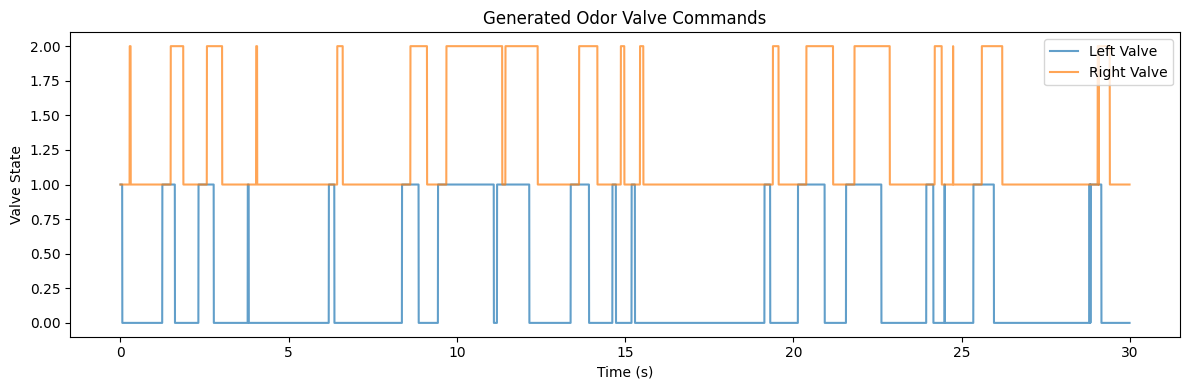

In [21]:
plt.figure(figsize=(12, 4))
plt.plot(final_pair.t, final_pair.left, label="Left Valve", alpha=0.7)
plt.plot(final_pair.t, final_pair.right+1, label="Right Valve", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Valve State")
plt.title("Generated Odor Valve Commands")
plt.legend()
plt.tight_layout()
plt.show()